In [2]:
# Kerakli kutubxonalar
import torch                      # asosiy PyTorch kutubxonasi
import torch.nn as nn             # neyron tarmoq qatlamlari
import torch.nn.functional as F   # yordamchi funksiyalar (one_hot va h.k.)
import matplotlib.pyplot as plt   # grafik chizish uchun

# Natija har safar bir xil chiqishi uchun tasodifiylikni qotiramiz
torch.manual_seed(42)

print("PyTorch versiyasi:", torch.__version__)

PyTorch versiyasi: 2.11.0+cu128


In [3]:
sequence = "maktab"

print("Ketma-ketlik", sequence)
print("Uzunligi:", len(sequence))

Ketma-ketlik maktab
Uzunligi: 6


In [4]:
chars = sorted(list(set(sequence)))
print("Harflar:", chars)
print("Uzunligi:", len(chars))

Harflar: ['a', 'b', 'k', 'm', 't']
Uzunligi: 5


In [5]:
char2Idx = {ch: i for i, ch in enumerate(chars)}
print(char2Idx)

idx2char = {i: ch for i, ch in enumerate(chars)}
print(idx2char)

{'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}
{0: 'a', 1: 'b', 2: 'k', 3: 'm', 4: 't'}


In [6]:
x_data = [char2Idx for char in sequence[:-1]]
y_data = [char2Idx for char in sequence[1:]]
print(x_data)
print(y_data)

[{'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}, {'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}, {'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}, {'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}, {'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}]
[{'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}, {'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}, {'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}, {'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}, {'a': 0, 'b': 1, 'k': 2, 'm': 3, 't': 4}]


In [7]:
# x_data ni one-hot vektorlarga aylantiramiz va batch o'lchovini qo'shamiz
# Shakl: (5, 1, 5) = (seq_len, batch, vocab_size)

vocab_size = len(chars)
x_data = [char2Idx[char] for char in sequence[:-1]]
y_data = [char2Idx[char] for char in sequence[1:]]

x = F.one_hot(torch.tensor(x_data), num_classes=vocab_size).float().unsqueeze(1)

# y_data oddiy indekslar bo'lib qoladi (CrossEntropyLoss indeks kutadi)
# Shakl: (5, 1)
y = torch.tensor(y_data).unsqueeze(1)

print("x shakli:", x.shape, " (seq_len, batch, vocab_size)")
print("y shakli:", y.shape, " (seq_len, batch)")
print("\nBirinchi harf 'm' ning one-hot ko'rinishi:", x[0].tolist())

x shakli: torch.Size([5, 1, 5])  (seq_len, batch, vocab_size)
y shakli: torch.Size([5, 1])  (seq_len, batch)

Birinchi harf 'm' ning one-hot ko'rinishi: [[0.0, 0.0, 0.0, 1.0, 0.0]]


In [8]:
class HarfRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        # Ota klass (nn.Module) ni ishga tushiramiz
        super(HarfRNN, self).__init__()

        self.hidden_size = hidden_size

        # RNN qatlami: harfni qabul qilib, xotira (hidden) holatini yangilaydi
        self.rnn = nn.RNN(input_size, hidden_size)

        # Chiziqli qatlam: xotiradan har bir harf uchun ball chiqaradi
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        # 1) RNN dan o'tkazamiz -> chiqish va yangilangan xotira
        out, hidden = self.rnn(x, hidden)

        # 2) Chiqishni chiziqli qatlamga beramiz -> vocab_size ta ball
        out = self.fc(out)

        # 3) Natija va yangi xotirani qaytaramiz
        return out, hidden


print("HarfRNN klassi tayyor.")

HarfRNN klassi tayyor.


In [9]:
# Giperparametrlar
hidden_size = 10   # xotira (hidden state) o'lchami
lr = 0.02          # o'rganish tezligi (learning rate)
epochs = 200       # epoxalar soni

# Model: kirish ham, chiqish ham vocab_size ga teng
model = HarfRNN(vocab_size, hidden_size, vocab_size)

# Yo'qotish funksiyasi: qaysi harf to'g'ri ekanini baholaydi
criterion = nn.CrossEntropyLoss()

# Optimizator: model og'irliklarini yangilaydi
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print(model)

HarfRNN(
  (rnn): RNN(5, 10)
  (fc): Linear(in_features=10, out_features=5, bias=True)
)


In [10]:
loss_history = []   # grafik chizish uchun har bir epoxa loss qiymati

for epoch in range(1, epochs + 1):
    # Har epoxa boshida xotirani nollaymiz: (qatlamlar, batch, hidden_size)
    hidden = torch.zeros(1, 1, hidden_size)

    loss = 0        # shu epoxadagi umumiy yo'qotish
    outputs = []    # model bashorat qilgan harf indekslari

    # Ketma-ketlik bo'ylab harfma-harf yuramiz
    for i in range(x.size(0)):
        # Bitta harfni modelga beramiz, xotirani ham uzatamiz
        out, hidden = model(x[i:i + 1], hidden)

        # Shu qadamdagi yo'qotishni umumiy loss ga qo'shamiz
        loss = loss + criterion(out.view(1, -1), y[i])

        # Eng yuqori ball olgan harfni bashorat sifatida saqlaymiz
        outputs.append(out.view(-1).argmax().item())

    # Gradientlarni nollaymiz -> hisoblaymiz -> og'irliklarni yangilaymiz
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # Har 20 epoxada natijani chiqaramiz
    if epoch % 20 == 0:
        pred_seq = "".join(idx2char[i] for i in outputs)
        print(f"Epoch: {epoch:3d} | Loss: {loss.item():.4f} | Pred: {sequence[0]}{pred_seq}")

Epoch:  20 | Loss: 1.3751 | Pred: maktab
Epoch:  40 | Loss: 0.1203 | Pred: maktab
Epoch:  60 | Loss: 0.0421 | Pred: maktab
Epoch:  80 | Loss: 0.0269 | Pred: maktab
Epoch: 100 | Loss: 0.0203 | Pred: maktab
Epoch: 120 | Loss: 0.0162 | Pred: maktab
Epoch: 140 | Loss: 0.0134 | Pred: maktab
Epoch: 160 | Loss: 0.0112 | Pred: maktab
Epoch: 180 | Loss: 0.0096 | Pred: maktab
Epoch: 200 | Loss: 0.0083 | Pred: maktab


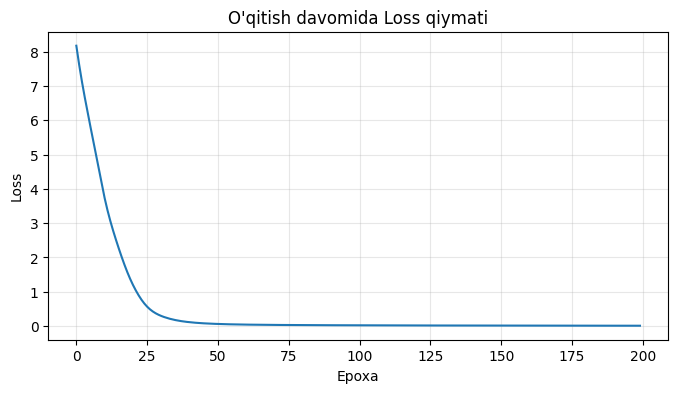

Boshlang'ich loss: 8.1763
Oxirgi loss:      0.0083


In [11]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)                      # har bir epoxadagi loss
plt.title("O'qitish davomida Loss qiymati")
plt.xlabel("Epoxa")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Boshlang'ich loss: {loss_history[0]:.4f}")
print(f"Oxirgi loss:      {loss_history[-1]:.4f}")

In [12]:
with torch.no_grad():
    hidden = torch.zeros(1, 1, hidden_size)
    natija = sequence[0]   # birinchi harfni modelga beramiz

    for i in range(x.size(0)):
        out, hidden = model(x[i:i + 1], hidden)
        natija += idx2char[out.view(-1).argmax().item()]

print("Asl so'z:   ", sequence)
print("Bashorat:   ", natija)
print("To'g'rimi?  ", "Ha " if natija == sequence else "Yo'q ")

Asl so'z:    maktab
Bashorat:    maktab
To'g'rimi?   Ha 


In [13]:
with torch.no_grad():
    hidden = torch.zeros(1, 1, hidden_size)
    joriy = sequence[0]        # faqat BIRINCHI harf beriladi
    natija = joriy

    for _ in range(len(sequence) - 1):
        # har qadamda modelning O'Z bashoratini one-hot qilib qaytadan beramiz
        kirish = F.one_hot(torch.tensor([char2Idx[joriy]]),
                           num_classes=vocab_size).float().unsqueeze(1)
        out, hidden = model(kirish, hidden)
        joriy = idx2char[out.view(-1).argmax().item()]   # bashorat -> keyingi kirish
        natija += joriy

print("Erkin generatsiya:", natija)

Erkin generatsiya: maktab


In [19]:
def bashorat(kirish, nechta=1, top_k=3):
    """Berilgan harflardan keyin keladigan harf(lar)ni bashorat qiladi.

    kirish  — foydalanuvchi kiritgan harflar (masalan "mak")
    nechta  — nechta harf bashorat qilinsin
    top_k   — birinchi bashorat uchun eng ehtimolli nechta variant ko'rsatilsin
    """
    kirish = kirish.strip().lower()          # normalizatsiya: "MAK " -> "mak"

    # --- Validatsiya (prod kodining eng muhim qismi) ---
    if not kirish:
        return {"xato": "Bo'sh kirish"}
    noma = sorted({c for c in kirish if c not in char2Idx})
    if noma:
        return {"xato": f"Lug'atda yo'q harf(lar): {', '.join(noma)}. "
                        f"Mavjud: {', '.join(chars)}"}

    model.eval()                              # inference rejimi
    with torch.no_grad():                     # gradient kerak emas
        hidden = torch.zeros(1, 1, hidden_size)

        # 1) Kirishni harfma-harf "o'qitamiz" — xotirani to'ldirish uchun
        for ch in kirish:
            inp = F.one_hot(torch.tensor([char2Idx[ch]]),
                            num_classes=vocab_size).float().unsqueeze(1)
            out, hidden = model(inp, hidden)

        # 2) Endi bashorat qilamiz; har bir bashorat keyingi kirishga aylanadi
        natija, top = "", None
        for i in range(nechta):
            p = torch.softmax(out.view(-1), 0)
            if i == 0:                        # ishonch darajasi faqat 1-qadam uchun
                v, idx = p.topk(min(top_k, vocab_size))
                top = [(idx2char[int(j)], float(q)) for q, j in zip(v, idx)]
            keyingi = idx2char[int(p.argmax())]
            natija += keyingi
            inp = F.one_hot(torch.tensor([char2Idx[keyingi]]),
                            num_classes=vocab_size).float().unsqueeze(1)
            out, hidden = model(inp, hidden)

    return {"kirish": kirish, "bashorat": natija,
            "toliq": kirish + natija, "top": top}

In [21]:
print(f"Model {len(chars)} ta harfni biladi: {', '.join(chars)}")
print("Chiqish uchun: q\n")

while True:
    s = input("Harflar kiriting: ")
    if s.strip().lower() in ("q", "quit", "exit"):
        print("Tugadi.")
        break

    r = bashorat(s, nechta=5)
    if "xato" in r:
        print("  ⚠", r["xato"], "\n")
        continue

    top = " | ".join(f"{c}: {p*100:.1f}%" for c, p in r["top"])
    print(f"  Bashorat : {r['kirish']} + {r['bashorat']}  →  {r['toliq']}")
    print(f"  Ishonch  : {top}\n")

Model 5 ta harfni biladi: a, b, k, m, t
Chiqish uchun: q



KeyboardInterrupt: Interrupted by user